# Data Collection

In [5]:
import pandas as pd
# Load Dataset
df = pd.read_csv("car.csv") 
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
# Dataset Shape
print("Dataset Shape:", df.shape)
print("\nRows:", df.shape[0])
print("Columns:", df.shape[1])

Dataset Shape: (301, 9)

Rows: 301
Columns: 9


In [3]:
# Column Names
print(df.columns)

Index(['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Kms_Driven',
       'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner'],
      dtype='object')


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [7]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


# Data Preprocessing

In [9]:
# Check Missing Values
print(df.isnull().sum()) # To verify any columns contains missing data

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


In [10]:
# Check Duplicate Records
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 2


In [11]:
#To remove duplicate rows
df = df.drop_duplicates()
print("New Shape:", df.shape)

New Shape: (299, 9)


In [12]:
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [13]:
print(df.dtypes) # check data types

Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Kms_Driven         int64
Fuel_Type         object
Seller_Type       object
Transmission      object
Owner              int64
dtype: object


In [15]:
# To identify categorical algorithms
categorical_columns=df.select_dtypes(include=['object'])
print(categorical_columns.columns)

Index(['Car_Name', 'Fuel_Type', 'Seller_Type', 'Transmission'], dtype='object')


# Exploratory Data Analysis
- Analyze distributions
- Understand relationships between variables
- Identify patterns and insights

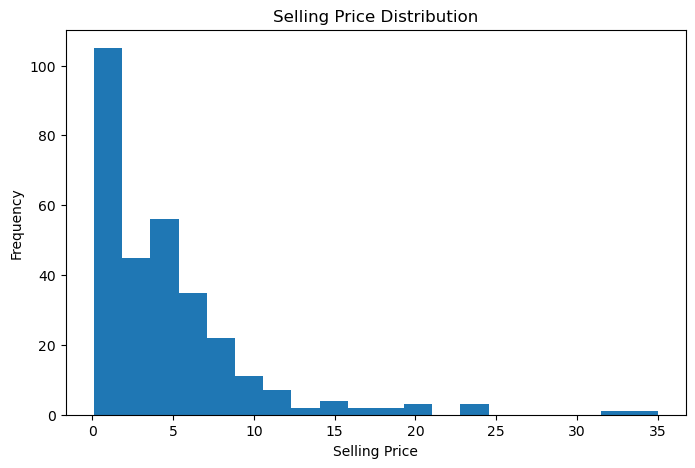

In [18]:
# shows how car selling prices are distributed in the dataset
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.hist(df['Selling_Price'], bins=20)
plt.title("Selling Price Distribution")
plt.xlabel("Selling Price")
plt.ylabel("Frequency")
plt.show()

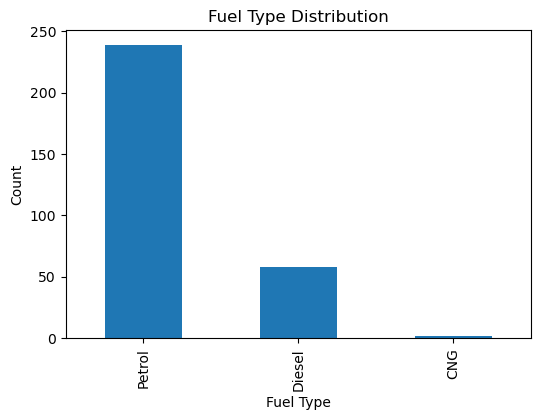

In [20]:
# To identify which fuel types are most common
df['Fuel_Type'].value_counts().plot(kind='bar',figsize=(6,4))
plt.title("Fuel Type Distribution")
plt.xlabel("Fuel Type")
plt.ylabel("Count")
plt.show()

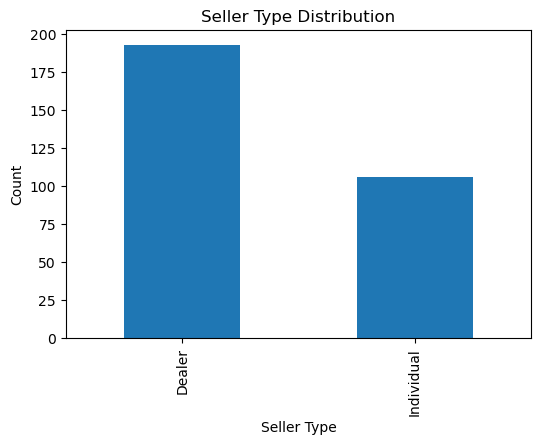

In [21]:
# To identify who sold more cars
df['Seller_Type'].value_counts().plot(kind='bar',figsize=(6,4))
plt.title("Seller Type Distribution")
plt.xlabel("Seller Type")
plt.ylabel("Count")
plt.show()

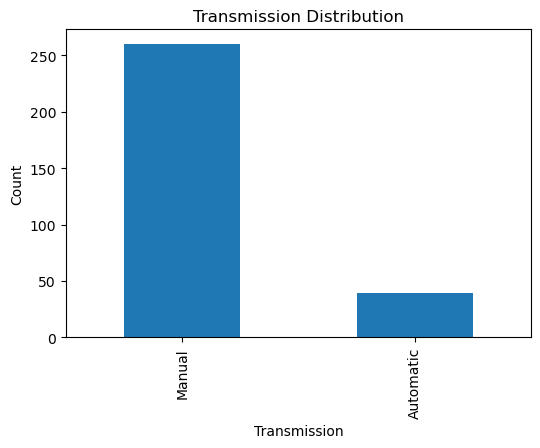

In [22]:
# Shows the proportion of manual vs automatic cars
df['Transmission'].value_counts().plot(kind='bar',figsize=(6,4))
plt.title("Transmission Distribution")
plt.xlabel("Transmission")
plt.ylabel("Count")
plt.show()

In [24]:
# Identifies relationships between numerical features and the target variable
eda_df = df.copy()
eda_df['Fuel_Type'] = eda_df['Fuel_Type'].astype('category').cat.codes
eda_df['Seller_Type'] = eda_df['Seller_Type'].astype('category').cat.codes
eda_df['Transmission'] = eda_df['Transmission'].astype('category').cat.codes

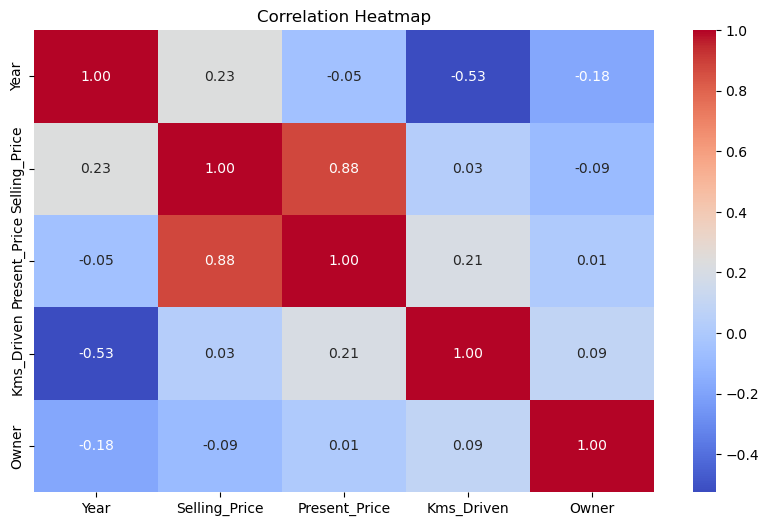

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
numeric_df = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(10,6))
sns.heatmap(numeric_df.corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

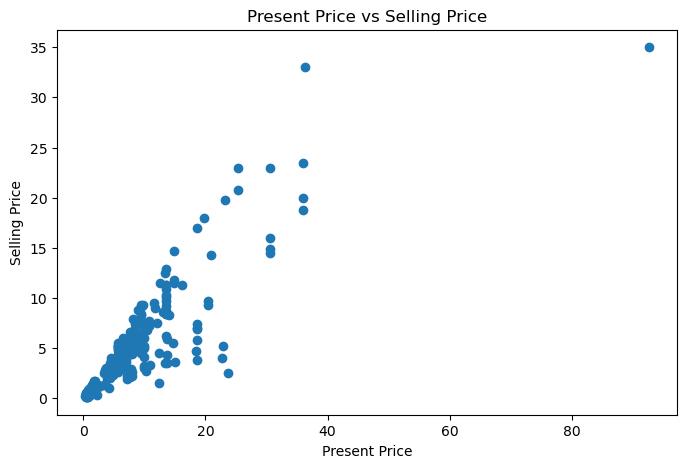

In [28]:
# Visualizes the relationship between showroom price and selling price.
plt.figure(figsize=(8,5))
plt.scatter(df['Present_Price'],df['Selling_Price'])
plt.xlabel("Present Price")
plt.ylabel("Selling Price")
plt.title("Present Price vs Selling Price")
plt.show()

# Feature Engineering
- Extract relevant features
- transform variables if needed,
- prepare data for model training

In [30]:
df['Car_Age'] = 2026 - df['Year']
df[['Year', 'Car_Age']].head()

,Year,Car_Age
0,2014,12
1,2013,13
2,2017,9
3,2011,15
4,2014,12


In [31]:
print(df[['Year', 'Car_Age']].head())

   Year  Car_Age
0  2014       12
1  2013       13
2  2017        9
3  2011       15
4  2014       12


In [32]:
df = df.drop(['Car_Name'], axis=1)
df.head()

,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


In [33]:
df = df.drop(['Year'], axis=1)
df.head()

,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,Car_Age
0,3.35,5.59,27000,Petrol,Dealer,Manual,0,12
1,4.75,9.54,43000,Diesel,Dealer,Manual,0,13
2,7.25,9.85,6900,Petrol,Dealer,Manual,0,9
3,2.85,4.15,5200,Petrol,Dealer,Manual,0,15
4,4.60,6.87,42450,Diesel,Dealer,Manual,0,12


In [34]:
print(df.columns)

Index(['Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type',
       'Seller_Type', 'Transmission', 'Owner', 'Car_Age'],
      dtype='object')


# Encoding Categorical Variables
- Handle categorical variables
- Prepare data for model training

In [35]:
# Check unique Values
print(df['Fuel_Type'].unique())
print(df['Seller_Type'].unique())
print(df['Transmission'].unique())

['Petrol' 'Diesel' 'CNG']
['Dealer' 'Individual']
['Manual' 'Automatic']


In [42]:
print(df.dtypes)

Selling_Price             float64
Present_Price             float64
Kms_Driven                  int64
Owner                       int64
Car_Age                     int64
Fuel_Type_Diesel             bool
Fuel_Type_Petrol             bool
Seller_Type_Individual       bool
Transmission_Manual          bool
dtype: object


In [45]:
print(df.columns)

Index(['Selling_Price', 'Present_Price', 'Kms_Driven', 'Owner', 'Car_Age',
       'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Seller_Type_Individual',
       'Transmission_Manual'],
      dtype='object')


# Train-Test Split
- Data Splitting:
Split the dataset into training and test sets
to evaluate model performance.

In [48]:
X = df.drop('Selling_Price',axis=1) # Features
y=df['Selling_Price'] # Target
print("X Shape:",X.shape)
print("y Shape:",y.shape)

X Shape: (299, 8)
y Shape: (299,)


In [50]:
# Split Dataset
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42)
print("Training Data:",X_train.shape)
print("Testing Data:",X_test.shape)

Training Data: (239, 8)
Testing Data: (60, 8)


# Model Selectio
- Choose an appropriate Machine Learning Algorithm.
- Random forest Regressor is selected

In [52]:
from sklearn.ensemble import RandomForestRegressor
model= RandomForestRegressor(n_estimators=100,random_state=42)
# creates 100 decision trees and ensure reproducible results

In [54]:
model.fit(X_train,y_train)
y_pred=model.predict(X_test)

In [55]:
predictions=pd.DataFrame({
    'Actual Price':y_test.values,
    'Predicted Price':y_pred
})
predictions.head(10)

,Actual Price,Predicted Price
0,8.99,9.4873
1,8.35,8.2615
2,0.45,0.4424
3,7.45,6.9605
4,5.25,16.8175
5,5.25,5.3095
6,5.85,7.0260
7,1.15,1.1770
8,9.25,7.8375
9,0.38,0.2825


# Model Evaluation
- Evaluates models performance usinf MSE and RSE

In [57]:
from sklearn.metrics import mean_squared_error,r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 Score:", r2)

Mean Squared Error (MSE): 11.665224829666673
Root Mean Squared Error (RMSE): 3.4154391854733226
R2 Score: 0.547390441726516


# Visualization of results

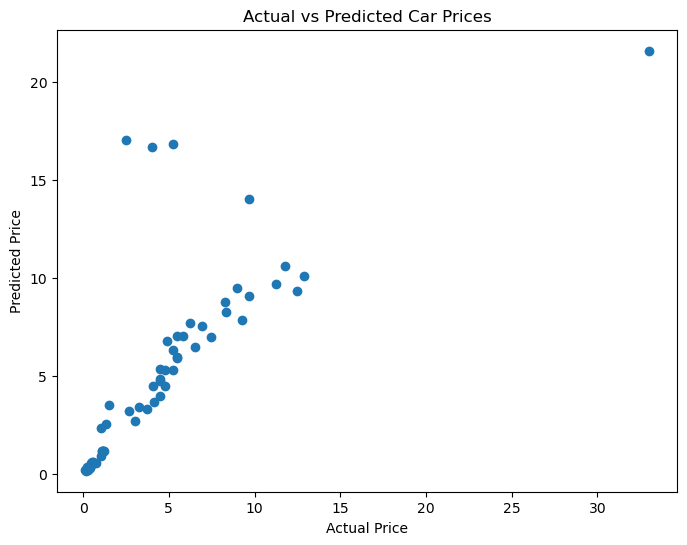

In [60]:
# Actual vs Predicted prices
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Car Prices")

plt.show()

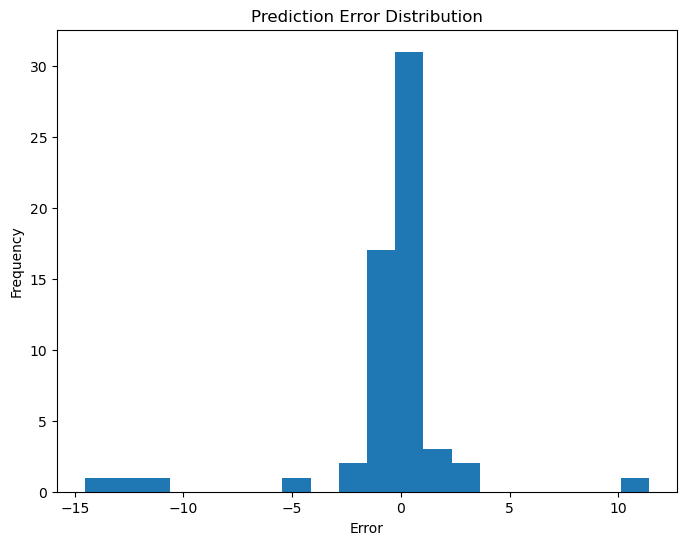

In [59]:
# Prediction error distribution
errors = y_test - y_pred

plt.figure(figsize=(8,6))

plt.hist(errors, bins=20)

plt.title("Prediction Error Distribution")

plt.xlabel("Error")

plt.ylabel("Frequency")

plt.show()

In [61]:
# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance

,Feature,Importance
0,Present_Price,0.905623
3,Car_Age,0.071841
1,Kms_Driven,0.013396
7,Transmission_Manual,0.005249
6,Seller_Type_Individual,0.002081
5,Fuel_Type_Petrol,0.000914
4,Fuel_Type_Diesel,0.000886
2,Owner,0.000010


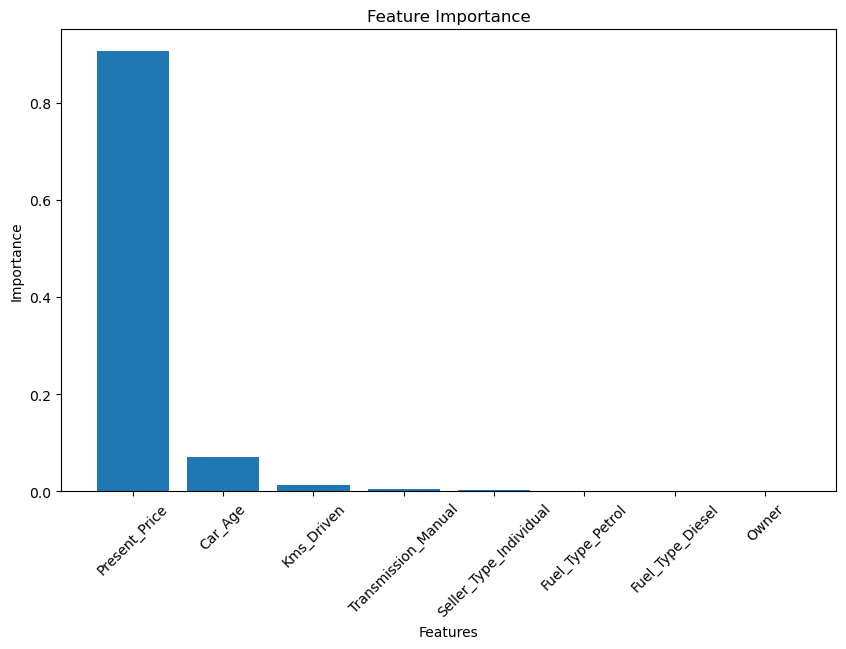

In [62]:
plt.figure(figsize=(10,6))

plt.bar(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xticks(rotation=45)

plt.title("Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.show()

# Hyperparameter Tuning

In [64]:
from sklearn.model_selection import RandomizedSearchCV
random_grid = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

In [65]:
rf = RandomForestRegressor(random_state=42)
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=random_grid,
    n_iter=20,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [66]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [5, 10, 15, 20, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300, 400,
                                                         500]},
                   random_state=42, verbose=2)

In [67]:
print(random_search.best_params_)

{'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}


In [68]:
best_model = random_search.best_estimator_

In [69]:
y_pred_tuned = best_model.predict(X_test)

In [70]:
mse_tuned = mean_squared_error(y_test, y_pred_tuned)

rmse_tuned = np.sqrt(mse_tuned)

r2_tuned = r2_score(y_test, y_pred_tuned)

print("Tuned MSE:", mse_tuned)

print("Tuned RMSE:", rmse_tuned)

print("Tuned R²:", r2_tuned)

Tuned MSE: 6.262907524944438
Tuned RMSE: 2.502580173529799
Tuned R²: 0.7569998135686357


In [71]:
import joblib

joblib.dump(best_model, "car_price_model.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [72]:
import os

print(os.listdir())

['.ipynb_checkpoints', 'Car-price.ipynb', 'car.csv', 'car_price_model.pkl']
